<a href="https://colab.research.google.com/github/JJCG25/Chagas---Machine-Learning/blob/main/Complicaciones_Totales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Libraries**

In [ ]:
!pip install catboost -q
!pip install pyswarms -q
!pip install sdv -q
!pip install DataSynthesizer -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import numpy as np

from google.colab import drive
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_recall_curve, recall_score,
    roc_auc_score, precision_score, roc_curve, balanced_accuracy_score,
    precision_recall_fscore_support, confusion_matrix, recall_score, average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer


sns.set_theme(style="whitegrid")   # cleaner than default
from copy import deepcopy

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS')
print(os.getcwd())

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS


#**Load Dataset**

In [ ]:
path= 'Base_tesis_chagas_IA_250725.xlsx'
chagas = pd.read_excel(path)
#chagas.head()

In [ ]:
#@title Turning the zeros in the Echocardiographic Variables into NaN's
cols_to_fix = ["ind vol final sistole", "índice E/E", "velocidad E´","diametro AI","TAPSE","presion sVD","índice de masa miocárdica","indice vol final diastole"]
for col in cols_to_fix:
  chagas.loc[chagas[col] == 0, col] = np.nan

In [ ]:
#@title Removing a Ghost Row from the Dataset
chagas = chagas.iloc[:-1]

In [ ]:
#@title Filling NaN values that Corresponded to Zeros
chagas['Años de fumador'] = chagas['Años de fumador'].fillna(0)
chagas['número de cigarrillos diarios'] = chagas['número de cigarrillos diarios'].fillna(0)
chagas['IPA'] = chagas['IPA'].fillna(0)
chagas['Mortalidad tiempo'] = chagas['Mortalidad tiempo'].fillna(0)
#Assuming for its sake, that these people aren't taking those drugs
chagas['BB'] = chagas['BB'].fillna(0)
chagas['IECAs/ARAII'] = chagas['IECAs/ARAII'].fillna(0)

In [ ]:
#@title One-hot encoding Dummies
chagas = pd.get_dummies(chagas, columns=['NYHA','AHA','estadocivil','arearesidencia','regimensalud','educacion'])

In [ ]:
#@title Dropping the Non-useful variables
chagas = chagas.drop(columns=["Primera dosis","segunda dosis","Tercera dosis","Cuarta dosis", 'Vacunación COVID',
                 'Tipo vacuna',"Mortalidad tiempo","Fuma actualmente", "número de cigarrillos diarios",
                 "Años de fumador", 'IMCat','Tipo vacuna.1','Tipo vacuna.2','Tipo vacuna.3','cod',
                 'fechaingreso', 'anioingreso', 'Fecha aplicación','Fecha aplicación.1',
                 'Fecha aplicación.2','Fecha aplicación.3', 'Fecha mortalidad', 'Fecha trasplante',
                 'Fecha asistencia'])

chagas.drop(columns=['índice E/E','velocidad E´','presion sVD','Complicaciones total',
                 'Asistencia','Trasplante','ACV','Mortalidad','Mortalidad menor a 2 años'], inplace=True)

chagas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 78 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1036 non-null   float64
 1   edad                                              1036 non-null   float64
 2   sexo                                              1036 non-null   float64
 3   IPA                                               1036 non-null   float64
 4   Consumo alcohol                                   1036 non-null   float64
 5   Peso                                              1036 non-null   float64
 6   Talla                                             1036 non-null   float64
 7   IMC                                               1036 non-null   float64
 8   FC                                                1036 non-null   float64
 9   PAS                

#**Defining a Datasets**

In [ ]:
#@title Full Columns
df_full = chagas.dropna(axis=1)
XX = df_full.drop(columns=['Complicaciones cardiovasculares'])
yy = df_full['Complicaciones cardiovasculares']

df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   tipodepaciente                   1036 non-null   float64
 1   edad                             1036 non-null   float64
 2   sexo                             1036 non-null   float64
 3   IPA                              1036 non-null   float64
 4   Consumo alcohol                  1036 non-null   float64
 5   Peso                             1036 non-null   float64
 6   Talla                            1036 non-null   float64
 7   IMC                              1036 non-null   float64
 8   FC                               1036 non-null   float64
 9   PAS                              1036 non-null   float64
 10  Comorbilidad rxcv                1036 non-null   float64
 11  Diabetes                         1036 non-null   float64
 12  EPOC                

In [ ]:
#@title Filling with the mean
df_mean = chagas.copy()
y = df_mean['Complicaciones cardiovasculares']
X = df_mean.drop(columns=['Complicaciones cardiovasculares'])
X = X.fillna(X.mean())
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 77 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1036 non-null   float64
 1   edad                                              1036 non-null   float64
 2   sexo                                              1036 non-null   float64
 3   IPA                                               1036 non-null   float64
 4   Consumo alcohol                                   1036 non-null   float64
 5   Peso                                              1036 non-null   float64
 6   Talla                                             1036 non-null   float64
 7   IMC                                               1036 non-null   float64
 8   FC                                                1036 non-null   float64
 9   PAS                

#**Gridsearch**

In [ ]:
#@title Gridsearch y Niveles de completitud
# =====================================================
# Función de métricas
# =====================================================
def calculate_metrics(y_true, y_pred, y_proba, model_name, completeness):
    return {
        'Completeness': completeness,
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'Specificity': recall_score(y_true, y_pred, pos_label=0),
        'AUROC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba)
    }
# =====================================================
# Expanded Parameter Grids per Model
# =====================================================
param_grids = {
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'p': [1, 2],
        'weights': ['uniform', 'distance'],
        'leaf_size': [20, 30, 40]
    },

    "SVM (RBF)": {
        'C': [0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
        'kernel': ['rbf']
    },

    "Random Forest": {
        'n_estimators': [100, 200, 400],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False],
        'class_weight': ['balanced']
    },

    "Decision Tree": {
        'max_depth': [3, 5, 10, 20, None],
        'criterion': ['gini', 'entropy', 'log_loss'],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced']
    },

    "Bagging (DT)": {
        'n_estimators': [50, 100, 200],
        'max_samples': [0.6, 0.8, 1.0],
        'max_features': [0.6, 0.8, 1.0],
        'bootstrap': [True, False]
    },

    "AdaBoost (DT)": {
        'n_estimators': [50, 100, 200, 400],
        'learning_rate': [0.001, 0.01, 0.1, 1.0],
        'estimator__max_depth': [1, 2, 3, 5]
    },

    "XGBoost": {
      'n_estimators': [100, 200],
      'max_depth': [3, 5, 7],
      'learning_rate': [0.01, 0.1],
      'reg_lambda': [1, 5]
  },

    "LightGBM": {
      'n_estimators': [200, 300],
      'learning_rate': [0.01, 0.1],
      'num_leaves': [31, 63],
      'max_depth': [-1, 10]
  },

    "CatBoost": {
      'depth': [4, 6, 8],
      'learning_rate': [0.01, 0.1],
      'l2_leaf_reg': [3, 5, 7]
  }
}


# =====================================================
# Loop por niveles de completitud
# =====================================================
results = []
completeness = chagas.notna().mean()
compt_v = [1]#, 0.95, 0.9, 0.8

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for a in compt_v:
    print(f"\n=== Completeness {a} ===")
    data = chagas.loc[:, completeness >= a].dropna()
    print(len(data.columns))
    print(len(data['Mortalidad menor a 2 años']))
    X = data.drop(columns=['Mortalidad menor a 2 años'])
    y = data['Mortalidad menor a 2 años']

    # Cálculo de pesos de clase
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_weights = dict(zip(classes, weights))

    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    scale_pos_weight = n_neg / n_pos

    # =====================================================
    # Modelos con pesos balanceados
    # =====================================================
    models = {
        "KNN": KNeighborsClassifier(),

        "SVM (RBF)": SVC(probability=True, class_weight='balanced'),

        "Random Forest": RandomForestClassifier(
            class_weight='balanced', random_state=42
        ),

        "Decision Tree": DecisionTreeClassifier(
            class_weight='balanced', random_state=42
        ),

        "Bagging (DT)": BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            random_state=42
        ),

        "AdaBoost (DT)": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            random_state=42
        ),

        "XGBoost": XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        ),

        "LightGBM": LGBMClassifier(
            is_unbalance=True,
            random_state=42
        ),

        "CatBoost": CatBoostClassifier(
            class_weights=[class_weights[0], class_weights[1]],
            verbose=0,
            random_state=42
        )
    }

    # =====================================================
    # GridSearch por modelo
    # =====================================================
    for name, model in models.items():
        print(f"\n--- GridSearch for {name} ---")

        grid_search = GridSearchCV(
            model,
            param_grids[name],
            cv=skf,
            scoring='f1',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X, y)
        best_model = grid_search.best_estimator_

        print(f"Best params for {name}: {grid_search.best_params_}")

        # cross_val_predict con el mejor modelo
        y_pred = cross_val_predict(best_model, X, y, cv=skf, method='predict')
        y_proba = cross_val_predict(best_model, X, y, cv=skf, method='predict_proba')[:, 1]

        metrics = calculate_metrics(y, y_pred, y_proba, name, a)
        results.append(metrics)


# =====================================================
# Consolidar resultados
# =====================================================
df_results = pd.DataFrame(results).round(4)

for comp in sorted(df_results['Completeness'].unique(), reverse=True):
    print(f"\n=== Completeness {comp} ===\n")
    table = (
        df_results[df_results['Completeness'] == comp]
        .set_index('Model')
        .drop(columns=['Completeness'])
    )
    print(table)



=== Completeness 1 ===
38
1036

--- GridSearch for KNN ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits
✅ Best params for KNN: {'leaf_size': 20, 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}

--- GridSearch for SVM (RBF) ---
Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Best params for SVM (RBF): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

--- GridSearch for Random Forest ---
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Best params for Random Forest: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

--- GridSearch for Decision Tree ---
Fitting 5 folds for each of 135 candidates, totalling 675 fits
✅ Best params for Decision Tree: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

--- GridSearch for Bagging (DT) ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Best

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best params for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'reg_lambda': 5}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:04:04] WARNING: /w


--- GridSearch for LightGBM ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best params for LightGBM: {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}

--- GridSearch for CatBoost ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Best params for CatBoost: {'depth': 4, 'l2_leaf_reg': 7, 'learning_rate': 0.01}

=== Completeness 1 ===

               Accuracy  Precision  Recall  F1-Score  Specificity   AUROC  \
Model                                                                       
KNN              0.7790     0.3798  0.2475    0.2997       0.9045  0.6593   
SVM (RBF)        0.6815     0.3507  0.7828    0.4844       0.6575  0.7898   
Random Forest    0.7539     0.4211  0.7677    0.5438       0.7506  0.7977   
Decision Tree    0.6786     0.3427  0.7424    0.4689       0.6635  0.7273   
Bagging (DT)     0.7664     0.3764  0.3384    0.3564       0.8675  0.6386   
AdaBoost (DT)    0.7249     0.3827  0.7172    0.4991      

##Extracting Feature Importance from Tree-Based Models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mean, y_mean, test_size=0.2, random_state=42, stratify=y
)

pd.set_option("display.max_rows", None)

# ======================================================
# Helper function to normalize importance formats
# ======================================================
def to_df(importances, columns):
    """Convert feature importances (Series, array, or DataFrame) to a uniform DataFrame."""
    if isinstance(importances, pd.Series):
        df = importances.reset_index()
        df.columns = ["feature", "importance"]
    elif isinstance(importances, np.ndarray):
        df = pd.DataFrame({"feature": columns, "importance": importances})
    elif isinstance(importances, pd.DataFrame):
        df = importances[["feature", "importance"]]
    else:
        raise TypeError("Unsupported format for importances")
    df = df.sort_values(by="importance", ascending=False).reset_index(drop=True)
    return df

# ======================================================
# Models
# ======================================================

Rf1 = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced',
                             criterion='gini', random_state=42)
Rf2 = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced',
                             criterion='entropy', random_state=42)
Rf3 = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced',
                             criterion='log_loss', random_state=42)

dt = DecisionTreeClassifier(class_weight='balanced', criterion='entropy', max_depth=5, random_state=42)

bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50, max_samples=1.0, random_state=42
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=200, learning_rate=0.01, random_state=42
)

xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.01, max_depth=3,
    use_label_encoder=False, eval_metric="logloss", random_state=42
)

lgb = LGBMClassifier(
    n_estimators=200, learning_rate=0.01, num_leaves=31, random_state=42, verbose=-1
)

cat = CatBoostClassifier(
    iterations=200, learning_rate=0.01, depth=4, verbose=0, random_state=42
)

svm = SVC(C=1000, gamma='scale', kernel='rbf', probability=True, random_state=42)

# ======================================================
# Compute importances and store them uniformly
# ======================================================
all_importances = []

# --- Random Forests ---
for model, name in zip([Rf1, Rf2, Rf3], ["RF-Gini", "RF-Entropy", "RF-LogLoss"]):
    model.fit(X_train, y_train)
    df = to_df(model.feature_importances_, X_train.columns)
    print(f"\n{name}\n", df.head(10))
    all_importances.append(df)

# --- AdaBoost ---
ada.fit(X_train, y_train)
df_ada = to_df(ada.feature_importances_, X_train.columns)
print("\nAdaBoost\n", df_ada.head(10))
all_importances.append(df_ada)

# --- Bagging ---
bag_dt.fit(X_train, y_train)
bag_imp = np.mean([tree.feature_importances_ for tree in bag_dt.estimators_], axis=0)
df_bag = to_df(bag_imp, X_train.columns)
print("\nBagging (DT)\n", df_bag.head(10))
all_importances.append(df_bag)

# --- XGBoost ---
xgb.fit(X_train, y_train)
df_xgb = to_df(xgb.feature_importances_, X_train.columns)
print("\nXGBoost\n", df_xgb.head(10))
all_importances.append(df_xgb)

# --- LightGBM ---
lgb.fit(X_train, y_train)
imp_lgb = lgb.feature_importances_.astype(float)
imp_lgb /= imp_lgb.sum()
df_lgb = to_df(imp_lgb, X_train.columns)
print("\nLightGBM\n", df_lgb.head(10))
all_importances.append(df_lgb)

# --- CatBoost ---
cat.fit(X_train, y_train)
imp_cat = cat.feature_importances_.astype(float)
imp_cat /= imp_cat.sum()
df_cat = to_df(imp_cat, X_train.columns)
print("\nCatBoost\n", df_cat.head(10))
all_importances.append(df_cat)

# ======================================================
# Combine and average importances
# ======================================================
combined = pd.concat(all_importances, ignore_index=True)
agg = (
    combined.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n=== TOP 10 FEATURES (AVERAGED ACROSS MODELS) ===")
print(agg.head(10))



RF-Gini
                                             feature  importance
0                                         NT proBNP    0.122066
1                                             RDW 1    0.081687
2                                              fevi    0.080877
3                                               BUN    0.040439
4                                     Heoglobina 1     0.036339
5                                               LMR    0.030428
6  Concentración de Hemoglobina Crospucular Media 1    0.030207
7                                        creatinina    0.030203
8                                              Peso    0.029831
9                             Linfocitos porcentaje    0.024979

RF-Entropy
                                             feature  importance
0                                         NT proBNP    0.136406
1                                             RDW 1    0.079040
2                                              fevi    0.078515
3                

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:30:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
                   feature  importance
0               NT proBNP    0.133348
1                   RDW 1    0.059931
2                    fevi    0.050631
3                     PLR    0.046579
4              creatinina    0.044712
5                    Peso    0.043498
6   Linfocitos porcentaje    0.043002
7                     BUN    0.041159
8                     PAS    0.040973
9  Neutrofilos porcentaje    0.037370

LightGBM
                      feature  importance
0                  NT proBNP    0.114543
1              Heoglobina 1     0.061112
2                       Peso    0.055602
3                       fevi    0.049090
4                       edad    0.040741
5                        BUN    0.039239
6                    potasio    0.037569
7  Globulos Rojos 1 x 10^6/u    0.036567
8                        PAS    0.033228
9                        IMC    0.032894

CatBoost
                                             feature  importance
0                                  

/tmp/ipython-input-3500044544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10['importance'], y=top10['feature'], palette='viridis')


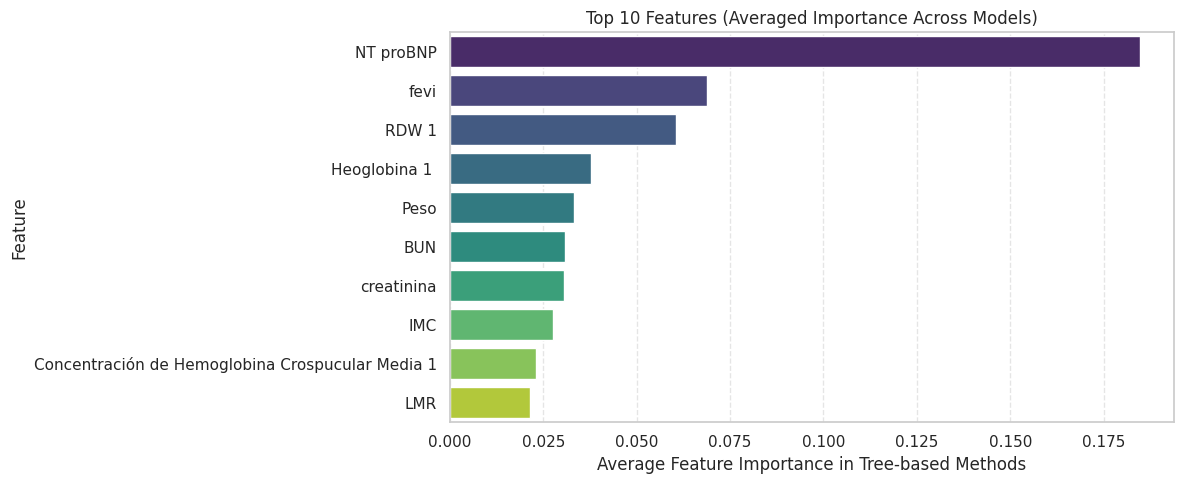

In [ ]:
top10 = agg.head(10)

# Graficamos
plt.figure(figsize=(12, 5))
sns.barplot(x=top10['importance'], y=top10['feature'], palette='viridis')

# Etiquetas y título
plt.xlabel('Average Feature Importance in Tree-based Methods')
plt.ylabel('Feature')
plt.title('Top 10 Features (Averaged Importance Across Models)')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

##Extracting Feature Importance from Permutation Importance

In [ ]:
# ======================================================
# Permutation Importance for all tuned models
# ======================================================

from sklearn.inspection import permutation_importance

# --- Define tuned models ---
knn = KNeighborsClassifier(
    leaf_size=20, n_neighbors=3, p=1, weights='uniform',class_weight='balanced'
)

svm = SVC(
    C=1, gamma='scale', kernel='rbf',
    probability=True, random_state=42, class_weight='balanced'
)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    min_samples_leaf=2, min_samples_split=5,
    bootstrap=False, class_weight='balanced',
    random_state=42
)

dt = DecisionTreeClassifier(
    class_weight='balanced', criterion='gini',
    max_depth=5, min_samples_leaf=4,
    min_samples_split=2, random_state=42
)

bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    n_estimators=50, max_samples=1.0,
    max_features=1.0, bootstrap=False,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42,class_weight='balanced'),
    n_estimators=50, learning_rate=0.1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.01,
    max_depth=3, reg_lambda=5,
    eval_metric='logloss', random_state=42
)

lgb = LGBMClassifier(
    n_estimators=200, learning_rate=0.01,
    num_leaves=31, max_depth=-1,
    random_state=42, verbose=-1
)

cat = CatBoostClassifier(
    iterations=200, learning_rate=0.01,
    depth=4, l2_leaf_reg=7,
    verbose=0, random_state=42
)

# ======================================================
# Compute permutation importances uniformly
# ======================================================

all_importances = []

models = {
    "KNN": knn,
    "SVM (RBF)": svm,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Bagging (DT)": bag_dt,
    "AdaBoost (DT)": ada,
    "XGBoost": xgb,
    "LightGBM": lgb,
    "CatBoost": cat
}

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    df_imp = to_df(result.importances_mean, X_test.columns)
    df_imp["model"] = name
    print(df_imp.head(10))
    all_importances.append(df_imp)

# ======================================================
# Combine and average importances
# ======================================================
combined = pd.concat(all_importances, ignore_index=True)
agg = (
    combined.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n=== TOP 10 FEATURES (AVERAGED PERMUTATION IMPORTANCE) ===")
print(agg.head(10))


--- KNN ---
                     feature  importance model
0                  NT proBNP    0.055288   KNN
1                         FC    0.012981   KNN
2                       fevi    0.011058   KNN
3  índice de masa miocárdica    0.011058   KNN
4                       Peso    0.008654   KNN
5    Recuento de plaquetas 1    0.004327   KNN
6  indice vol final diastole    0.003846   KNN
7      ind vol final sistole    0.000962   KNN
8             tipodepaciente    0.000000   KNN
9    Demencia (Dxco Médico)     0.000000   KNN

--- SVM (RBF) ---
           feature  importance      model
0        NT proBNP    0.057692  SVM (RBF)
1             edad    0.000000  SVM (RBF)
2             sexo    0.000000  SVM (RBF)
3              IPA    0.000000  SVM (RBF)
4  Consumo alcohol    0.000000  SVM (RBF)
5             Peso    0.000000  SVM (RBF)
6            Talla    0.000000  SVM (RBF)
7              IMC    0.000000  SVM (RBF)
8               FC    0.000000  SVM (RBF)
9              PAS    0.000000 

TypeError: barplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 800x500 with 0 Axes>

/tmp/ipython-input-1552835596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10['importance'], y=top10['feature'], palette='viridis')


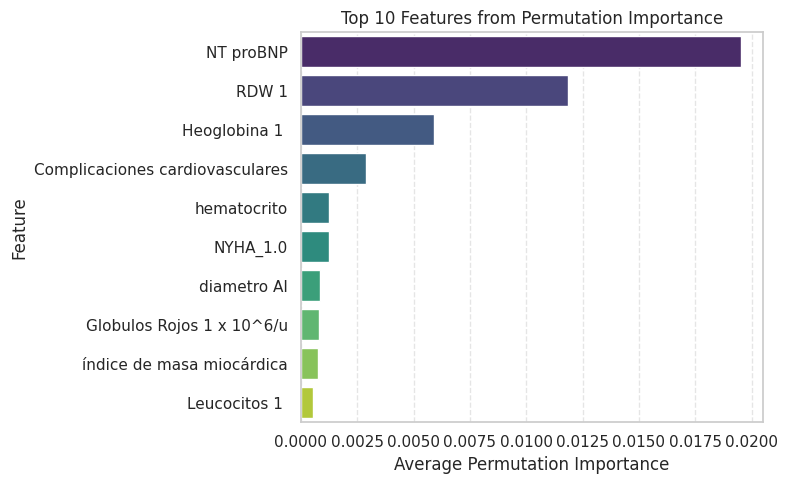

In [ ]:
top10 = agg.head(10)

# Graficamos
plt.figure(figsize=(8, 5))
sns.barplot(x=top10['importance'], y=top10['feature'], palette='viridis')

# Etiquetas y título
plt.xlabel('Average Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features from Permutation Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

#**Data Balancing Techiniques**

In [ ]:
#@title Modelos y metricas
models = {
  "KNN": KNeighborsClassifier(leaf_size=20, n_neighbors=3, p=1, weights='uniform'),
  "SVM (RBF)": SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=42),
  "Random Forest": RandomForestClassifier(
      n_estimators=100, max_depth=5, min_samples_leaf=2, min_samples_split=5,
      bootstrap=False, class_weight='balanced', random_state=42
  ),
  "Decision Tree": DecisionTreeClassifier(
      class_weight='balanced', criterion='gini',
      max_depth=5, min_samples_leaf=4, min_samples_split=2, random_state=42
  ),
  "Bagging (DT)": BaggingClassifier(
      estimator=DecisionTreeClassifier(random_state=42),
      n_estimators=50, max_samples=1.0, max_features=1.0,
      bootstrap=False, random_state=42
  ),
  "AdaBoost (DT)": AdaBoostClassifier(
      estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
      n_estimators=50, learning_rate=0.1, random_state=42
  ),
  "XGBoost": XGBClassifier(
      n_estimators=200, learning_rate=0.01, max_depth=3,
      reg_lambda=5, eval_metric='logloss', random_state=42
  ),
  "LightGBM": LGBMClassifier(
      n_estimators=200, learning_rate=0.01, num_leaves=31,
      max_depth=-1, random_state=42, verbose=-1
  ),
  "CatBoost": CatBoostClassifier(
      iterations=200, learning_rate=0.01, depth=4,
      l2_leaf_reg=7, verbose=0, random_state=42
  ),
}

def calculate_metrics(y_true, y_pred, y_proba, model_name,Fold=1):
    return {
        'Fold':Fold,
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'Specificity': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'AUROC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba)
    }

In [ ]:
#@title Run all models pasando el split ya hecho
def run_all_models(X_train, y_train, X_test, y_test):
    """
    Entrena todos los modelos definidos en 'models' usando un split 70-30
    que el usuario proporciona externamente.
    No aplica ningún tipo de sampling.
    """

    # ===== Estadísticas básicas =====
    print("\n=== Entrenamiento sin sampling ===")
    print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"Tamaño y_train: {y_train.shape}, y_test: {y_test.shape}")

    print("\nDistribución de clases en y_train:")
    print(y_train.value_counts())

    print("\nDistribución de clases en y_test:")
    print(y_test.value_counts())

    # ===== Escalado solo para KNN y SVM =====
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ===== Resultados =====
    results = []

    for name, model in models.items():

        # Modelos que requieren escalado
        if name in ['KNN', 'SVM (RBF)']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
            else:
                # Para modelos sin predict_proba (raro en estos dos)
                y_proba = np.zeros_like(y_pred)

        else:
            # Modelos normales sin escalado
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)[:, 1]
            else:
                y_proba = np.zeros_like(y_pred)

        # Guardar métricas
        results.append(
            calculate_metrics(y_test, y_pred, y_proba, name)
        )

    # ===== Resultados finales =====
    df_all = pd.DataFrame(results)
    print("\n=== Resultados del Test (70-30) ===")
    print(df_all.sort_values(by='F1-Score', ascending=False))

    return df_all


In [ ]:
#@title Run all models con K-fold
def run_all_models_kfold(X, y, k=5, models=None):
    print(f"\n======= Stratified {k}-Fold Cross Validation =======")

    # Cálculo de pesos de clase
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_weights = dict(zip(classes, weights))

    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    scale_pos_weight = n_neg / n_pos

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    best_global_model = None
    best_global_score = -1
    best_global_name = None
    all_metrics=[]

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_means = X_train.mean(numeric_only=True)
        #test_means = X_test.mean(numeric_only=True) No uso la mean de test, imputo con la de train
        X_train = X_train.fillna(train_means)
        X_test = X_test.fillna(train_means)

        print(f"\nFold {fold}/{k}")
        #print(f"\nMedia imputada \n: {train_means}")

        print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")
        print(f"Tamaño y_train: {y_train.shape}, y_test: {y_test.shape}")
        print(f"\nDistribución de clases en y_train: {y_train.value_counts(normalize=False).to_string()}")
        print(f"\nDistribución de clases en y_test: {y_test.value_counts(normalize=False).to_string()}")

        # Escalado
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        fold_metrics=[]
        for name, model in models.items():
            #print(f"→ {name}")

            if name in ['KNN', 'SVM (RBF)']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
                '''if name == "SVM (RBF)":
                  print(f"    SVM Fold {fold} predictions summary:")
                  print(f"    Predicted positives: {(y_pred == 1).sum()} / {len(y_pred)}")
                  print(f"    True positives in y_test: {(y_test == 1).sum()} / {len(y_test)}")
                  print(f"    Predicted all same class? {np.all(y_pred == y_pred[0])}")
                  print(f"    Unique predictions: {np.unique(y_pred)}")
                  print(f"    Fold F1: {f1_score(y_test, y_pred, zero_division=0):.3f}\n")'''
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1]

            metrics = calculate_metrics(y_test, y_pred, y_proba, name,fold)
            fold_metrics.append(metrics)
            all_metrics.append(metrics)

            if metrics['F1-Score'] > best_global_score:
                best_global_score = metrics['F1-Score']
                best_global_model = deepcopy(model)
                best_global_name = name

        df_fold = pd.DataFrame([m for m in fold_metrics if m['Fold'] == fold]).sort_values(by='F1-Score', ascending=False)
        print(df_fold.to_string(index=False))

    df_all = pd.DataFrame(all_metrics)
    df_all.drop(columns=['Fold'], inplace=True)
    # Agrupar por modelo y calcular media y desviación estándar
    df_avg = df_all.groupby('Model').agg(['mean']).round(4)

    print("\n=== Promedio Final de Todos los Folds ===")
    print(df_avg.sort_values(by=('F1-Score', 'mean'), ascending=False))

    print(f"\n Mejor modelo global: {best_global_name} (F1 = {best_global_score:.4f})")

    return best_global_model, best_global_name

In [ ]:
model, name = run_all_models_kfold(X_mean, y_mean, k=10, models=models)


======= Stratified 10-Fold Cross Validation =======

Fold 1/10
Tamaño X_train: (932, 77), X_test: (104, 77)
Tamaño y_train: (932,), y_test: (104,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    876
1.0     56

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    98
1.0     6
 Fold         Model  Accuracy  Precision   Recall  F1-Score  Specificity    AUROC   PR-AUC
    1 Decision Tree  0.567308   0.102041 0.833333  0.181818     0.551020 0.664966 0.090463
    1           KNN  0.942308   0.000000 0.000000  0.000000     1.000000 0.751701 0.152564
    1     SVM (RBF)  0.942308   0.000000 0.000000  0.000000     1.000000 0.654762 0.249194
    1 Random Forest  0.817308   0.000000 0.000000  0.000000     0.867347 0.687075 0.108373
    1  Bagging (DT)  0.875000   0.000000 0.000000  0.000000     0.928571 0.433673 0.057692
    1 AdaBoost (DT)  0.942308   0.000000 0.000000  0.000000     1.000000 0.819728 0.466518
    1       XGBoost  0.942308   0.0000

In [ ]:
def run_all_models_sampling(X_train, y_train,X_test,y_test, sampling=None):
    if sampling == "over":
        sampler = RandomOverSampler(random_state=42)
        X_train, y_train = sampler.fit_resample(X_train, y_train)
        print("\nOversampling aplicado al conjunto de entrenamiento.")
    elif sampling == "under":
        sampler = RandomUnderSampler(random_state=42)
        X_train, y_train = sampler.fit_resample(X_train, y_train)
        print("\nUndersampling aplicado al conjunto de entrenamiento.")
    elif sampling == "smote":
        sampler = SMOTE(random_state=42, k_neighbors=5)
        X_train, y_train = sampler.fit_resample(X_train, y_train)
        print("\nSMOTE aplicado (oversampling sintético).")
    else:
        print("\nSin resampling aplicado.")

    print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"Tamaño y_train: {y_train.shape}, y_test: {y_test.shape}")
    print(f"\nDistribución de clases en y_train: {y_train.value_counts(normalize=False).to_string()}")
    print(f"\nDistribución de clases en y_test: {y_test.value_counts(normalize=False).to_string()}")

    # === Escalado para KNN y SVM ===
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    results = []

    # === Entrenamiento y evaluación ===
    for name, model in models.items():
        #print(f"\n→ {name}")

        if name in ['KNN', 'SVM (RBF)']:
            model.fit(X_train_scaled, y_train)
            y_test_pred = model.predict(X_test_scaled)
            y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_test_pred = model.predict(X_test)
            y_test_proba = model.predict_proba(X_test)[:, 1]

        results.append(calculate_metrics(y_test, y_test_pred, y_test_proba, name))

    df_all = pd.DataFrame(results)
    print("\n=== Test Results ===")
    print(df_all.sort_values(by='F1-Score', ascending=False))

    return df_all

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

results = run_all_models_sampling(X_train, y_train,X_test,y_test, sampling='over')


Oversampling aplicado al conjunto de entrenamiento.
Tamaño X_train: (1168, 77), X_test: (415, 77)
Tamaño y_train: (1168,), y_test: (415,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    584
1.0    584

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    390
1.0     25

=== Test Results ===
   Fold          Model  Accuracy  Precision  Recall  F1-Score  Specificity  \
8     1       CatBoost  0.908434   0.240000    0.24  0.240000     0.951282   
2     1  Random Forest  0.910843   0.227273    0.20  0.212766     0.956410   
6     1        XGBoost  0.802410   0.109589    0.32  0.163265     0.833333   
3     1  Decision Tree  0.751807   0.102041    0.40  0.162602     0.774359   
0     1            KNN  0.828916   0.103448    0.24  0.144578     0.866667   
1     1      SVM (RBF)  0.925301   0.200000    0.08  0.114286     0.979487   
7     1       LightGBM  0.925301   0.125000    0.04  0.060606     0.982051   
4     1   Bagging (DT)  0.908434   0

In [ ]:
# Sin rebalanceo
df_base = run_all_models(X,y)

# Oversampling aleatorio
df_over = run_all_models(X,y, sampling='over')

# Undersampling aleatorio
df_under = run_all_models(X,y, sampling='under')

# SMOTE (sintético)
df_smote = run_all_models(X,y, sampling='smote')


Train / Test Split (70/30) 

Sin resampling aplicado.
Tamaño X_train: (725, 43), X_test: (311, 43)
Tamaño y_train: (725,), y_test: (311,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    682
1.0     43

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    292
1.0     19

=== Test Results ===
   Fold          Model  Accuracy  Precision    Recall  F1-Score  Specificity  \
2     1  Random Forest  0.787781   0.149254  0.526316  0.232558     0.804795   
3     1  Decision Tree  0.575563   0.093525  0.684211  0.164557     0.568493   
4     1   Bagging (DT)  0.877814   0.086957  0.105263  0.095238     0.928082   
0     1            KNN  0.922830   0.000000  0.000000  0.000000     0.982877   
1     1      SVM (RBF)  0.938907   0.000000  0.000000  0.000000     1.000000   
5     1  AdaBoost (DT)  0.938907   0.000000  0.000000  0.000000     1.000000   
6     1        XGBoost  0.938907   0.000000  0.000000  0.000000     1.000000   
7     1       LightG

## K-folds con sampling

In [ ]:
def run_all_models_kfold_with_sampling(X, y, k=5, models=None, sampling=None):
    print(f"\n======= Stratified {k}-Fold Cross Validation (with sampling) =======")

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    best_global_model = None
    best_global_score = -1
    best_global_name = None
    all_metrics = []
    all_metrics_full_data = []      # NUEVO: métricas en todo el dataset

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_means = X_train.mean(numeric_only=True)
        X_train = X_train.fillna(train_means)
        X_test = X_test.fillna(train_means)

        if sampling == "over":
            sampler = RandomOverSampler(random_state=42)
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        elif sampling == "under":
            sampler = RandomUnderSampler(random_state=42)
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        elif sampling == "smote":
            sampler = SMOTE(random_state=42, k_neighbors=5)
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")
        print(f"Tamaño y_train: {y_train.shape}, y_test: {y_test.shape}")
        print(f"\nDistribución de clases en y_train: {y_train.value_counts(normalize=False).to_string()}")
        print(f"\nDistribución de clases en y_test: {y_test.value_counts(normalize=False).to_string()}")


        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        fold_metrics = []

        for name, model in models.items():

            # Entrenamiento + evaluación en test
            if name in ['KNN', 'SVM (RBF)']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                y_proba = model.predict_proba(X_test_scaled)[:, 1]

                # ======== NUEVO: evaluar en TODO el dataset ========
                X_full_scaled = scaler.transform(X.fillna(train_means))
                y_pred_full = model.predict(X_full_scaled)
                y_proba_full = model.predict_proba(X_full_scaled)[:, 1]

            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1]

                # ======== NUEVO: evaluar en TODO el dataset ========
                X_full = X.fillna(train_means)
                y_pred_full = model.predict(X_full)
                y_proba_full = model.predict_proba(X_full)[:, 1]

            # métricas en test
            metrics = calculate_metrics(y_test, y_pred, y_proba, name, fold)
            fold_metrics.append(metrics)
            all_metrics.append(metrics)

            # métricas en todo X, y
            metrics_full = calculate_metrics(y, y_pred_full, y_proba_full, name, fold)
            all_metrics_full_data.append(metrics_full)

            # mantener mejor modelo global
            if metrics['F1-Score'] > best_global_score:
                best_global_score = metrics['F1-Score']
                best_global_model = deepcopy(model)
                best_global_name = name

        df_fold = pd.DataFrame(fold_metrics).sort_values(
            by='F1-Score', ascending=False
        )
        print(f"\n===== Fold {fold}/{k} =====")
        print(df_fold.to_string(index=False))

    df_all = pd.DataFrame(all_metrics)
    df_avg = df_all.groupby("Model").mean().round(4)

    print("\n=== Promedio Final de Todos los Folds ===")
    print(df_avg.sort_values(by='F1-Score', ascending=False))

    print(f"\n Mejor modelo global: {best_global_name} (F1 = {best_global_score:.4f})")

    # NUEVO: dataframe con evaluación en todo el dataset
    df_full_eval = pd.DataFrame(all_metrics_full_data)
    df_full_avg = df_full_eval.groupby("Model").mean().round(4)

    print("\n=== Evaluación en todo el dataset ===")
    print(df_full_avg.sort_values(by='F1-Score', ascending=False))

    return best_global_model, best_global_name

In [ ]:
model, name = run_all_models_kfold_with_sampling(X, y, k=10, models=models, sampling=None)


======= Stratified 10-Fold Cross Validation (with sampling) =======
Tamaño X_train: (932, 77), X_test: (104, 77)
Tamaño y_train: (932,), y_test: (104,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    876
1.0     56

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    98
1.0     6

===== Fold 1/10 =====
Tamaño X_train: (932, 77), X_test: (104, 77)
Tamaño y_train: (932,), y_test: (104,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    876
1.0     56

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    98
1.0     6

===== Fold 2/10 =====
Tamaño X_train: (932, 77), X_test: (104, 77)
Tamaño y_train: (932,), y_test: (104,)

Distribución de clases en y_train: Complicaciones cardiovasculares
0.0    876
1.0     56

Distribución de clases en y_test: Complicaciones cardiovasculares
0.0    98
1.0     6

===== Fold 3/10 =====
Tamaño X_train: (932, 77), X_test: (104, 77)
Tamaño y_train: (932,), y_test: (1

## **PSO**

In [ ]:
import numpy as np
from pyswarms.single.global_best import GlobalBestPSO
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = chagas.drop(columns=['Complicaciones cardiovasculares'])
y = chagas['Complicaciones cardiovasculares']

# división estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


train_means = X_train.mean(numeric_only=True)
X_train = X_train.fillna(train_means)
X_test = X_test.fillna(train_means)

# normalización Z-score
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train.values)
X_test_np  = scaler.transform(X_test.values)

In [ ]:
def fitness(particles):
    n_particles = particles.shape[0]
    scores = np.zeros(n_particles)

    for i, p in enumerate(particles):
        mask = p > 0.7

        if mask.sum() == 0:
            scores[i] = 1e6
            continue

        X_sel = X_train_np[:, mask]   # ahora sí es NumPy
        model = GaussianNB()
        model.fit(X_sel, y_train)

        y_pred = model.predict(X_test_np[:, mask])

        f1_major = f1_score(y_test, y_pred, pos_label=0)
        f1_minor = f1_score(y_test, y_pred, pos_label=1)

        P = 1 / X_train_np.shape[1]
        penalty = P * (mask.sum() ** 2)

        scores[i] = -(0.5*f1_major + 0.5*f1_minor) + penalty

    return scores

In [ ]:
n_vars = X_train_np.shape[1]

options = {'c1':1.8, 'c2':2.0, 'w':0.7}

optimizer = GlobalBestPSO(
    n_particles=30,
    dimensions=n_vars,
    options=options,
    bounds=(np.zeros(n_vars), np.ones(n_vars))
)

best_cost, best_pos = optimizer.optimize(fitness, iters=50)

2025-11-14 07:22:46,607 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.8, 'c2': 2.0, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.817
2025-11-14 07:23:10,313 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.8174045405965605, best pos: [0.55436528 0.51692203 0.55182393 0.3923781  0.46635836 0.34339783
 0.20639036 0.49235497 0.33366031 0.06476185 0.49436084 0.40280777
 0.33382545 0.64508617 0.80657533 0.62947586 0.07657322 0.27570326
 0.38059109 0.05681169 0.91859803 0.8592008  0.69062982 0.40580018
 0.28539427 0.58243517 0.88898759 0.12424017 0.63783628 0.19477979
 0.33988692 0.82657324 0.00928566 0.63004261 0.09563093 0.70271369
 0.22047592 0.53136558 0.08001007 0.6512409  0.37316376 0.78183507
 0.67870172 0.44955871 0.62294587 0.47635884 0.6655146  0.02235399
 0.23034455 0.7743675  0.13795285 0.37016347 0.56485813 0.62706135
 0.28328977 0.23061393 0.98875434 0.29064826 0.03899621 0.52243763
 0.56617265

In [ ]:
best_mask = best_pos > 0.7
selected_features = X.columns[best_mask]
print(selected_features)

Index(['Fibrilación atrial', 'BB', 'NT proBNP', 'BUN',
       'Volumen Corpuscular Medio 1', 'RDW 1', 'Basofilos 1', 'LMR',
       'indice vol final diastole', 'educacion_0.0'],
      dtype='object')


In [ ]:
X_train_sel = X_train_np[:, best_mask]
X_test_sel  = X_test_np[:, best_mask]

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_auc_score

model, name = run_all_models_kfold_with_sampling(X, y, k=10, models=models, sampling=None)


              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       196
         1.0       0.00      0.00      0.00        12

    accuracy                           0.93       208
   macro avg       0.47      0.49      0.48       208
weighted avg       0.89      0.93      0.91       208

AUC: 0.6632653061224489


## **STATISTICAL METHODS**

In [ ]:
#@title function fit
from copy import deepcopy
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sdv.metadata import SingleTableMetadata  # o Metadata si quieres la API nueva
from sdv.single_table import GaussianCopulaSynthesizer

def run_all_models_kfold_with_sampling(X, y, k=5, models=None, sampling=None, synth_multiplier=1.0):
    """
    sampling: None | "over" | "under" | "smote" | "GM"
    synth_multiplier: multiplicador para n_synthetic relativo al mayoritario
                      (por defecto 1.0 => balance perfecto)
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    best_global_model = None
    best_global_score = -1
    best_global_name = None
    all_metrics = []
    all_metrics_full_data = []

    # detect categorical / numeric on full X (but we will fit encoders only on X_train per fold)
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        # 1) split (real data only)
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

        #imputando con la media
        train_means = X_train.mean(numeric_only=True)
        X_train = X_train.fillna(train_means)
        X_test = X_test.fillna(train_means)

        # 2) handle simple missing values *temporarily* for metadata / synthetic generation:
        # create df_train (with label) for operations that require dataframe
        df_train = X_train.copy()
        df_train['Complicaciones cardiovasculares'] = y_train

        # 3) Sampling shortcuts (over/under/smote) BEFORE encoding (works on numeric + categorical if using sklearn-compatible)
        if sampling == "over":
            sampler = RandomOverSampler(random_state=42)
            X_train, y_train = sampler.fit_resample(X_train, y_train)
            df_train = X_train.copy(); df_train['Complicaciones cardiovasculares'] = y_train
        if sampling == "under":
            sampler = RandomUnderSampler(random_state=42)
            X_train, y_train = sampler.fit_resample(X_train, y_train)
            df_train = X_train.copy(); df_train['Complicaciones cardiovasculares'] = y_train
        if sampling == "smote":
            # SMOTE necesita datos numéricos — si tienes categóricas, deberías aplicar encoding antes de SMOTE.
            # Here we will postpone SMOTE handling (user can pass sampling='smote' only if they've pre-encoded numerics).
            sampler = SMOTE(random_state=42, k_neighbors=5)
            X_train, y_train = sampler.fit_resample(X_train, y_train)
            df_train = X_train.copy(); df_train['Complicaciones cardiovasculares'] = y_train

        # 4) GM path: generate synthetic minority using GaussianCopula built on df_min_train (from this fold)
        if sampling == "GM":
            # Use only the fold train (df_train) — NEVER use global X or X_train_real
            df_min_train = df_train[df_train['Complicaciones cardiovasculares'] == 1].reset_index(drop=True)
            df_maj_train = df_train[df_train['Complicaciones cardiovasculares'] == 0].reset_index(drop=True)

            # if minority too small, you may choose to skip or use augmenting multiplier
            if len(df_min_train) < 2:
                # skip synthesis for this fold
                synthetic_min = pd.DataFrame(columns=df_train.columns)
            else:
                # prepare metadata from df_min_train (SDV)
                metadata = SingleTableMetadata()
                metadata.detect_from_dataframe(df_min_train)

                gmodel = GaussianCopulaSynthesizer(metadata)
                gmodel.fit(df_min_train)

                # generate as many as needed to balance (or use synth_multiplier)
                n_needed = max(int(len(df_maj_train)*synth_multiplier) - len(df_min_train), 0)
                if n_needed > 0:
                    synthetic_min = gmodel.sample(n_needed)
                    # ensure same column order and column names
                    synthetic_min = synthetic_min[df_min_train.columns]
                    # label
                    synthetic_min['Complicaciones cardiovasculares'] = 1
                    print(synthetic_min.head())
                else:
                    synthetic_min = pd.DataFrame(columns=df_train.columns)

            # assemble augmented train
            df_train_augmented = pd.concat([df_maj_train, df_min_train, synthetic_min], ignore_index=True)
            df_train_augmented = df_train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

            X_train = df_train_augmented.drop(columns=['Complicaciones cardiovasculares'])
            y_train = df_train_augmented['Complicaciones cardiovasculares']
            # refresh df_train for downstream checks
            df_train = df_train_augmented.copy()

        # 5) Now build column transformer using ONLY X_train columns
        # determine categorical and numeric columns present in this fold
        categorical_cols_fold = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
        numeric_cols_fold = X_train.select_dtypes(include=[np.number]).columns.tolist()

        # pipelines: impute + encode/scale
        numeric_pipeline = make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        )
        categorical_pipeline = make_pipeline(
            SimpleImputer(strategy='constant', fill_value='Missing'),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_pipeline, numeric_cols_fold),
                ('cat', categorical_pipeline, categorical_cols_fold)
            ], remainder='drop'
        )

        # fit transformer on X_train only
        X_train_pre = preprocessor.fit_transform(X_train)
        # transform X_test and full X for evaluation
        X_test_pre = preprocessor.transform(X_test)
        X_full_pre = preprocessor.transform(X.fillna(X_train.median(numeric_only=True)))

        # 6) Entrenar y evaluar modelos (usar X_train_pre / X_test_pre)
        for name, model in models.items():
            m = deepcopy(model)
            # Fit on preprocessed training
            m.fit(X_train_pre, y_train)
            # Predict on fold test (real)
            y_pred = m.predict(X_test_pre)
            # Some models may not support predict_proba; handle safely
            if hasattr(m, "predict_proba"):
                y_proba = m.predict_proba(X_test_pre)[:, 1]
                y_proba_full = m.predict_proba(X_full_pre)[:, 1]
            else:
                # fallback: use decision_function if available and map to sigmoid
                if hasattr(m, "decision_function"):
                    df_dec = m.decision_function(X_test_pre)
                    # simple mapping to [0,1]
                    y_proba = 1/(1+np.exp(-df_dec))
                    df_dec_full = m.decision_function(X_full_pre)
                    y_proba_full = 1/(1+np.exp(-df_dec_full))
                else:
                    # last resort: fallback to predicted labels as probabilities
                    y_proba = m.predict(X_test_pre)
                    y_proba_full = m.predict(X_full_pre)

            # calcular métricas (supongo que tienes calculate_metrics)
            metrics = calculate_metrics(y_test, y_pred, y_proba, name, fold)
            all_metrics.append(metrics)

            # evaluación en todo X (opcional)
            y_pred_full = m.predict(X_full_pre)
            metrics_full = calculate_metrics(y, y_pred_full, y_proba_full, name, fold)
            all_metrics_full_data.append(metrics_full)

            # mantener mejor modelo global según F1 en test
            if metrics['F1-Score'] > best_global_score:
                best_global_score = metrics['F1-Score']
                best_global_model = deepcopy(m)
                best_global_name = name

        # print fold summary
        print(f"\nFold {fold}/{k}: X_train {X_train.shape}, X_test {X_test.shape}")
        print("y_train distribution:", y_train.value_counts().to_dict())
        print("y_test distribution:", y_test.value_counts().to_dict())

    # resumen final
    df_all = pd.DataFrame(all_metrics)
    df_avg = df_all.groupby("Model").mean().round(4)
    print("\n=== Promedio Final de Todos los Folds ===")
    print(df_avg.sort_values(by='F1-Score', ascending=False))

    df_full_eval = pd.DataFrame(all_metrics_full_data)
    df_full_avg = df_full_eval.groupby("Model").mean().round(4)
    print("\n=== Evaluación en todo el dataset ===")
    print(df_full_avg.sort_values(by='F1-Score', ascending=False))

    print(f"\n Mejor modelo global: {best_global_name} (F1 = {best_global_score:.4f})")
    return best_global_model, best_global_name

In [ ]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

X_train_real, X_test, y_train_real, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

df_train = X_train_real.copy()
df_train['Complicaciones cardiovasculares'] = y_train_real

df_min_train = df_train[df_train['Complicaciones cardiovasculares'] == 1]
df_maj_train = df_train[df_train['Complicaciones cardiovasculares'] == 0]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_train)

model = GaussianCopulaSynthesizer(metadata)
model.fit(df_min_train)
synthetic_min = model.sample(900)

#print(synthetic_min)
synthetic_min['Complicaciones cardiovasculares'] = 1

df_train_augmented = pd.concat([df_maj_train, synthetic_min], ignore_index=True)
df_train_augmented = df_train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)
df_train_augmented.head(50)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


,tipodepaciente,edad,sexo,IPA,Consumo alcohol,Peso,Talla,IMC,FC,PAS,PAD,Comorbilidad rxcv,Diabetes,EPOC,Fibrilación atrial,Demencia (Dxco Médico),Enfermedad arterial periférica,Hipertensión arterial,fevi,IECAs/ARAII,BB,NT proBNP,creatinina,potasio,glicemia,PCR,BUN,Globulos Rojos 1 x 10^6/u,Leucocitos 1,Heoglobina 1,hematocrito,Volumen Corpuscular Medio 1,Hemoglobina Corpuscular Media 1,Concentración de Hemoglobina Crospucular Media 1,Recuento de plaquetas 1,RDW 1,Volumen Plaquetario 1,Neutrofilos 1,Linfocitos 1,Monocitos 1,Eosinofilos 1,Basofilos 1,Neutrofilos porcentaje,Linfocitos porcentaje,Monocitos porcentaje,Eosinofilos porcentaje,Basofilos porcentaje,LR,PLR,LMR,NLR,ind vol final sistole,diametro diastole,diametro AI,TAPSE,índice de masa miocárdica,indice vol final diastole,NYHA_1.0,NYHA_2.0,NYHA_3.0,NYHA_4.0,AHA_1.0,AHA_2.0,AHA_3.0,AHA_4.0,estadocivil_0.0,estadocivil_1.0,estadocivil_2.0,arearesidencia_0.0,arearesidencia_1.0,regimensalud_0.0,regimensalud_1.0,educacion_0.0,educacion_1.0,educacion_2.0,educacion_3.0,educacion_4.0,Complicaciones cardiovasculares
0,1.0,54.0,0.0,0.0,0.0,49.7,1.59,21.374978,77.0,113.0,89.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,1.0,1.0,2227.655878,1.23,3.90,106.917369,14.546743,35.41,4.112925,6.688546,13.577103,41.086650,95.976797,29.680888,30.805153,200.080672,14.740980,9.812485,4.430105,0.550030,0.809700,0.031339,0.031645,74.481855,13.725197,11.218569,2.576362,0.541630,5.229051,172.193231,1.622181,2.565627,60.756469,5.546311,3.249515,17.601855,155.860826,122.507547,False,True,False,False,False,False,True,False,False,True,False,True,True,True,True,False,False,False,True,False,1.0
1,1.0,48.0,1.0,0.0,0.0,72.5,1.74,19.841095,80.0,83.0,83.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,11.0,1.0,1.0,2301.011903,1.69,4.07,126.104516,29.361943,36.27,4.143988,13.131570,12.218841,35.951932,88.389812,28.599186,32.161144,253.968445,13.953321,6.715824,12.217357,0.550027,0.616640,0.147628,0.086262,79.418017,11.684668,5.821340,1.709236,0.762581,6.881161,134.187856,1.697656,4.747431,123.449591,7.839970,4.051020,15.106142,159.527100,183.178006,False,False,False,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,False,False,1.0
2,1.0,68.0,0.0,0.0,0.0,62.0,1.65,21.355953,71.0,98.0,43.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,46.0,0.0,1.0,39.769508,1.92,4.81,95.195041,50.246821,17.98,3.998779,8.547030,14.312289,38.564085,96.834880,31.566541,32.906590,142.842072,14.539867,8.953802,6.622284,0.550025,0.515883,0.230011,0.042145,78.040983,16.368622,6.687512,2.779882,0.646095,5.227318,73.544276,4.400364,4.561816,150.170000,6.222481,3.839488,19.128562,113.090010,135.760675,False,True,False,False,False,False,True,False,True,True,False,True,False,True,False,False,False,False,False,False,1.0
3,0.0,74.0,0.0,0.0,0.0,50.0,1.51,21.928863,69.0,146.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0,0.0,0.0,85.890000,1.10,4.16,102.900000,0.890000,14.00,4.560154,7.997554,16.769629,42.009526,92.392090,29.732577,32.170513,216.843653,13.644372,8.841327,5.284326,1.802336,0.635180,0.208933,0.057349,64.002410,24.048800,8.224594,2.885677,0.792813,3.815223,141.259102,3.138825,2.661439,25.040000,4.500000,2.200000,22.000000,57.000000,61.060000,True,False,False,False,True,False,False,False,True,False,False,False,True,False,True,True,False,False,False,False,0.0
4,1.0,72.0,1.0,0.0,0.0,74.0,1.64,27.513385,75.0,102.0,77.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,20.0,1.0,1.0,35000.000000,2.85,4.49,158.400000,70.620000,38.87,5.440000,13.400000,16.100000,52.300000,96.100000,29.600000,30.800000,199.000000,12.400000,9.100000,9.740000,2.550000,1.030000,0.000000,0.060000,72.700000,19.000000,7.720000,0.070000,0.460000,3.819608,78.039216,2.475728,4.894472,62.362170,6.300000,3.600000,17.776204,152.550000,101.110991,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,False,True,False,False,0.0
5,1.0,79.0,1.0,0.0,0.0,79.4,1.57,29.513397,50.0,97.0,42.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,50.0,0.0,1.0,672.506769,1.35,4.33,117.886543,10.745032,11.46,4.6

In [ ]:
df_train_augmented.info()
X_train = df_train_augmented.drop(columns=['Complicaciones cardiovasculares'])
y_train = df_train_augmented['Complicaciones cardiovasculares']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1582 entries, 0 to 1581
Data columns (total 78 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1582 non-null   float64
 1   edad                                              1582 non-null   float64
 2   sexo                                              1582 non-null   float64
 3   IPA                                               1582 non-null   float64
 4   Consumo alcohol                                   1582 non-null   float64
 5   Peso                                              1582 non-null   float64
 6   Talla                                             1582 non-null   float64
 7   IMC                                               1582 non-null   float64
 8   FC                                                1582 non-null   float64
 9   PAS                

In [ ]:
X_train.info()
df_to = run_all_models(X_train, y_train,X_test,y_test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1582 entries, 0 to 1581
Data columns (total 77 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1582 non-null   float64
 1   edad                                              1582 non-null   float64
 2   sexo                                              1582 non-null   float64
 3   IPA                                               1582 non-null   float64
 4   Consumo alcohol                                   1582 non-null   float64
 5   Peso                                              1582 non-null   float64
 6   Talla                                             1582 non-null   float64
 7   IMC                                               1582 non-null   float64
 8   FC                                                1582 non-null   float64
 9   PAS                

In [ ]:
model, name = run_all_models_kfold_with_sampling(X, y, k=5, models=models, sampling='GM')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


   tipodepaciente  edad  sexo  IPA  Consumo alcohol  Peso  Talla        IMC  \
0             1.0  54.0   1.0  0.0              0.0  77.7   1.70  24.615634   
1             1.0  48.0   1.0  0.0              0.0  73.3   1.72  24.497916   
2             1.0  54.0   0.0  0.0              0.0  65.9   1.53  29.491056   
3             1.0  87.0   1.0  0.0              0.0  82.2   1.61  33.366124   
4             1.0  58.0   1.0  0.0              0.0  81.4   1.59  33.697780   

      FC    PAS   PAD  Comorbilidad rxcv  Diabetes   EPOC  Fibrilación atrial  \
0   62.0  114.0  62.0                1.0        0.0   0.0                 1.0   
1   65.0   94.0  68.0                0.0        0.0   0.0                 0.0   
2  116.0  131.0  72.0                1.0        0.0   0.0                 0.0   
3   37.0  124.0  37.0                0.0        0.0   0.0                 1.0   
4   66.0  112.0  75.0                0.0        0.0   0.0                 1.0   

   Demencia (Dxco Médico)   Enfermedad

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 1/5: X_train (1558, 77), X_test (208, 77)
y_train distribution: {1.0: 779, 0.0: 779}
y_test distribution: {0.0: 195, 1.0: 13}


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


...


Fold 4/5: X_train (1558, 77), X_test (207, 77)
y_train distribution: {1.0: 779, 0.0: 779}
y_test distribution: {0.0: 195, 1.0: 12}


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


   tipodepaciente  edad  sexo  IPA  Consumo alcohol  Peso  Talla        IMC  \
0             1.0  60.0   1.0  0.0              0.0  66.0   1.60  26.673661   
1             1.0  57.0   0.0  0.0              0.0  72.3   1.72  26.031880   
2             1.0  63.0   0.0  0.0              0.0  71.9   1.49  33.186174   
3             1.0  52.0   0.0  0.0              0.0  61.0   1.49  28.385036   
4             1.0  85.0   0.0  0.0              0.0  50.5   1.51  21.485786   

     FC    PAS   PAD  Comorbilidad rxcv  Diabetes   EPOC  Fibrilación atrial  \
0  66.0  116.0  84.0                0.0        0.0   0.0                 1.0   
1  46.0   88.0  65.0                1.0        0.0   0.0                 0.0   
2  99.0  104.0  80.0                0.0        0.0   0.0                 0.0   
3  63.0  118.0  68.0                1.0        0.0   0.0                 0.0   
4  53.0  129.0  59.0                1.0        0.0   0.0                 0.0   

   Demencia (Dxco Médico)   Enfermedad arter

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 5/5: X_train (1560, 77), X_test (207, 77)
y_train distribution: {1.0: 780, 0.0: 780}
y_test distribution: {0.0: 194, 1.0: 13}

=== Promedio Final de Todos los Folds ===
               Fold  Accuracy  Precision  Recall  F1-Score  Specificity  \
Model                                                                     
KNN             3.0    0.8784     0.1037  0.1256    0.1097       0.9260   
Bagging (DT)    3.0    0.8735     0.0639  0.0808    0.0706       0.9240   
Decision Tree   3.0    0.9151     0.0450  0.0321    0.0374       0.9712   
AdaBoost (DT)   3.0    0.9353     0.0667  0.0167    0.0267       0.9938   
SVM (RBF)       3.0    0.9324     0.0400  0.0154    0.0222       0.9907   
CatBoost        3.0    0.9325     0.0000  0.0000    0.0000       0.9918   
LightGBM        3.0    0.9382     0.0000  0.0000    0.0000       0.9979   
Random Forest   3.0    0.9392     0.0000  0.0000    0.0000       0.9990   
XGBoost         3.0    0.9353     0.0000  0.0000    0.0000       0.9949   


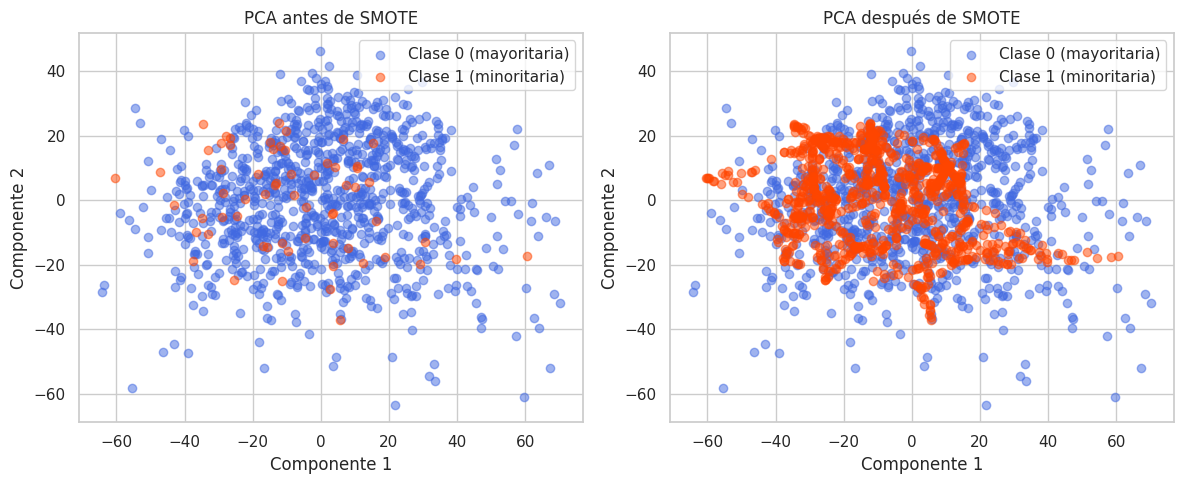

Varianza explicada antes de SMOTE: [0.35523541 0.20790034]
Varianza explicada después de SMOTE: [0.35523541 0.20790034]


In [ ]:
#@title PCA antes y despues de SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1️⃣ PCA antes de SMOTE
pca_before = PCA(n_components=2)
X_pca = pca_before.fit_transform(X)

sampler = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sampler.fit_resample(X, y)

# 2️⃣ PCA después de SMOTE
X_res_pca = pca_before.transform(X_res)

# 3️⃣ Visualización comparativa
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Antes de SMOTE ---
axs[0].scatter(X_pca[y==0,0], X_pca[y==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[0].scatter(X_pca[y==1,0], X_pca[y==1,1],
               c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
axs[0].set_title('PCA antes de SMOTE')
axs[0].set_xlabel('Componente 1')
axs[0].set_ylabel('Componente 2')
axs[0].legend()

# --- Después de SMOTE ---
axs[1].scatter(X_res_pca[y_res==0,0], X_res_pca[y_res==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[1].scatter(X_res_pca[y_res==1,0], X_res_pca[y_res==1,1],
               c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
axs[1].set_title('PCA después de SMOTE')
axs[1].set_xlabel('Componente 1')
axs[1].set_ylabel('Componente 2')
axs[1].legend()

plt.tight_layout()
plt.show()

# 4️⃣ Varianza explicada
print("Varianza explicada antes de SMOTE:", pca_before.explained_variance_ratio_)
print("Varianza explicada después de SMOTE:", pca_before.explained_variance_ratio_)

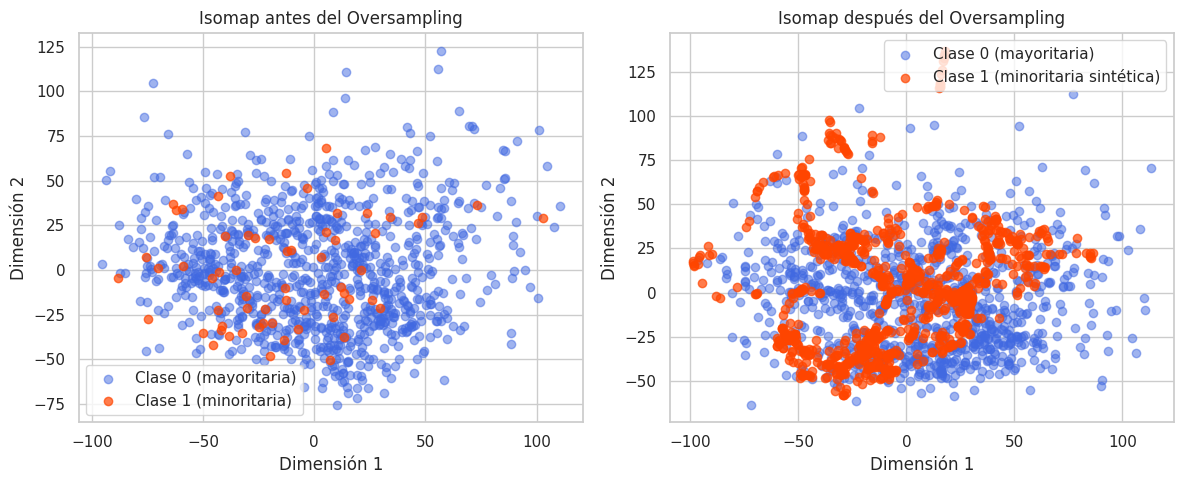

In [ ]:
#@title Isomap antes y despues de SMOTE
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt

# 1️⃣ Isomap ANTES de SMOTE
iso = Isomap(n_components=2)
X_iso = iso.fit_transform(X)     # Isomap ajustado en los datos reales

# Oversampling (puede ser SMOTE, GMM, etc.)
sampler = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sampler.fit_resample(X, y)

# 2️⃣ Isomap DESPUÉS de SMOTE (misma transformación)
X_res_iso = iso.transform(X_res)
# 3️⃣ Visualización comparativa
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Antes de SMOTE ---
axs[0].scatter(X_iso[y==0,0], X_iso[y==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[0].scatter(X_iso[y==1,0], X_iso[y==1,1],
               c='orangered', label='Clase 1 (minoritaria)', alpha=0.7)
axs[0].set_title('Isomap antes del Oversampling')
axs[0].set_xlabel('Dimensión 1')
axs[0].set_ylabel('Dimensión 2')
axs[0].legend()

# --- Después de SMOTE ---
axs[1].scatter(X_res_iso[y_res==0,0], X_res_iso[y_res==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[1].scatter(X_res_iso[y_res==1,0], X_res_iso[y_res==1,1],
               c='orangered', label='Clase 1 (minoritaria sintética)', alpha=0.7)
axs[1].set_title('Isomap después del Oversampling')
axs[1].set_xlabel('Dimensión 1')
axs[1].set_ylabel('Dimensión 2')
axs[1].legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


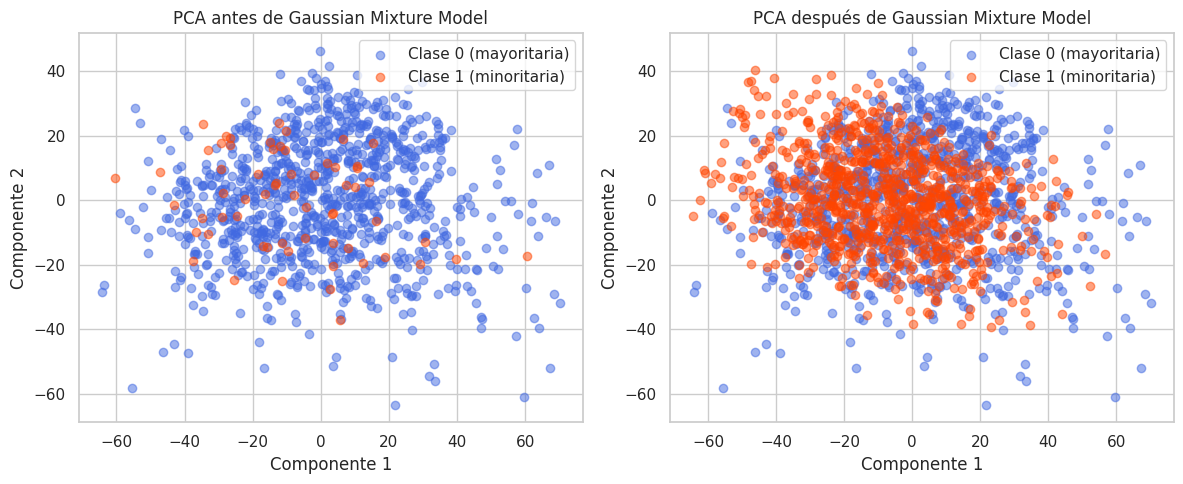

Varianza explicada antes de SMOTE: [0.35523541 0.20790034]
Varianza explicada después de SMOTE: [0.35523541 0.20790034]


In [ ]:
#@title PCA antes y despues de GaussianCopulaSynthesizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA antes de SMOTE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_train = X.copy()
df_train['Complicaciones cardiovasculares'] = y

df_min_train = df_train[df_train['Complicaciones cardiovasculares'] == 1]
df_maj_train = df_train[df_train['Complicaciones cardiovasculares'] == 0]

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_train)

model = GaussianCopulaSynthesizer(metadata)
model.fit(df_min_train)
synthetic_min = model.sample(900)

#print(synthetic_min)
synthetic_min['Complicaciones cardiovasculares'] = 1

df_train_augmented = pd.concat([df_maj_train, synthetic_min], ignore_index=True)
df_train_augmented = df_train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

X_res = df_train_augmented.drop(columns=['Complicaciones cardiovasculares'])
y_res = df_train_augmented['Complicaciones cardiovasculares']
# PCA después de SMOTE

X_res_pca = pca.transform(X_res)

# Visualización comparativa
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Antes de SMOTE ---
axs[0].scatter(X_pca[y==0,0], X_pca[y==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[0].scatter(X_pca[y==1,0], X_pca[y==1,1],
               c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
axs[0].set_title('PCA antes de Gaussian Mixture Model')
axs[0].set_xlabel('Componente 1')
axs[0].set_ylabel('Componente 2')
axs[0].legend()

# --- Después de SMOTE ---
axs[1].scatter(X_res_pca[y_res==0,0], X_res_pca[y_res==0,1],
               c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
axs[1].scatter(X_res_pca[y_res==1,0], X_res_pca[y_res==1,1],
               c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
axs[1].set_title('PCA después de Gaussian Mixture Model')
axs[1].set_xlabel('Componente 1')
axs[1].set_ylabel('Componente 2')
axs[1].legend()

plt.tight_layout()
plt.show()

# Varianza explicada
print("Varianza explicada antes de SMOTE:", pca_before.explained_variance_ratio_)
print("Varianza explicada después de SMOTE:", pca_before.explained_variance_ratio_)

In [ ]:
#@title Aplicar solo Gaussian Copula Synthesizer 70-30
def gm_oversampling_train_test(X, y, test_size=0.3, synth_multiplier=1.0, random_state=42):
    """
    Aplica Gaussian Copula SOLO al conjunto de entrenamiento
    en un split 70-30.

    synth_multiplier:
        1.0 => equilibra exactamente a la clase mayoritaria
        >1  => genera aún más sintéticos
    """

    # 1) División real (estratificada)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # 2) Imputación SOLO usando TRAIN
    train_means = X_train.mean(numeric_only=True)
    X_train = X_train.fillna(train_means)
    X_test = X_test.fillna(train_means)

    # 3) Unir X_train + y_train
    df_train = X_train.copy()
    df_train['Comp'] = y_train

    df_min = df_train[df_train['Comp'] == 1].reset_index(drop=True)
    df_maj = df_train[df_train['Comp'] == 0].reset_index(drop=True)

    # 4) Si hay muy pocos minoritarios, evitar GM
    if len(df_min) < 10:
        print("Minoría insuficiente para Gaussian Copula. Se devuelve TRAIN original.")
        return X_train, X_test, y_train, y_test

    # 5) Metadata del SDV (detecta categorías y numéricos)
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_min)

    # 6) Ajustar Gaussian Copula SOLO a etiqueda MINORÍA
    gmodel = GaussianCopulaSynthesizer(metadata)
    gmodel.fit(df_min)

    # 7) Cantidad de sintéticos a generar
    target_size = int(len(df_maj) * synth_multiplier)
    n_to_generate = max(target_size - len(df_min), 0)

    print(f"Generando {n_to_generate} registros sintéticos...")

    if n_to_generate > 0:
        synthetic_min = gmodel.sample(n_to_generate)
        synthetic_min = synthetic_min[df_min.columns]  # orden de columnas
        synthetic_min['Comp'] = 1
    else:
        synthetic_min = pd.DataFrame(columns=df_train.columns)

    # 8) Unir: mayoría + minoría real + sintéticos
    df_aug = pd.concat([df_maj, df_min, synthetic_min], ignore_index=True)
    df_aug = df_aug.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # 9) Separar X_train e y_train
    X_train_balanced = df_aug.drop(columns=['Comp'])
    y_train_balanced = df_aug['Comp']

    return X_train_balanced, X_test, y_train_balanced, y_test

In [ ]:
#@title Entrenando GaussianCopulaSynthesizer - Split 70-30
df_mean = chagas.copy()

y = df_mean['Complicaciones cardiovasculares']
X = df_mean.drop(columns=['Complicaciones cardiovasculares'])

X_train, X_test, y_train, y_test = gm_oversampling_train_test(X, y)
df_resultados = run_all_models(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generando 639 registros sintéticos...

=== Entrenamiento sin sampling ===
Tamaño X_train: (1364, 77), X_test: (311, 77)
Tamaño y_train: (1364,), y_test: (311,)

Distribución de clases en y_train:
Comp
0.0    682
1.0    682
Name: count, dtype: int64

Distribución de clases en y_test:
Complicaciones cardiovasculares
0.0    292
1.0     19
Name: count, dtype: int64

=== Resultados del Test (70-30) ===
   Fold          Model  Accuracy  Precision    Recall  F1-Score  Specificity  \
5     1  AdaBoost (DT)  0.938907   0.500000  0.052632  0.095238     0.996575   
0     1            KNN  0.845659   0.060606  0.105263  0.076923     0.893836   
3     1  Decision Tree  0.897106   0.066667  0.052632  0.058824     0.952055   
4     1   Bagging (DT)  0.881029   0.050000  0.052632  0.051282     0.934932   
2     1  Random Forest  0.938907   0.000000  0.000000  0.000000     1.000000   
1     1      SVM (RBF)  0.932476   0.000000  0.000000  0.000000     0.993151   
6     1        XGBoost  0.938907   0.00

Generando 912 muestras sintéticas con GMM...


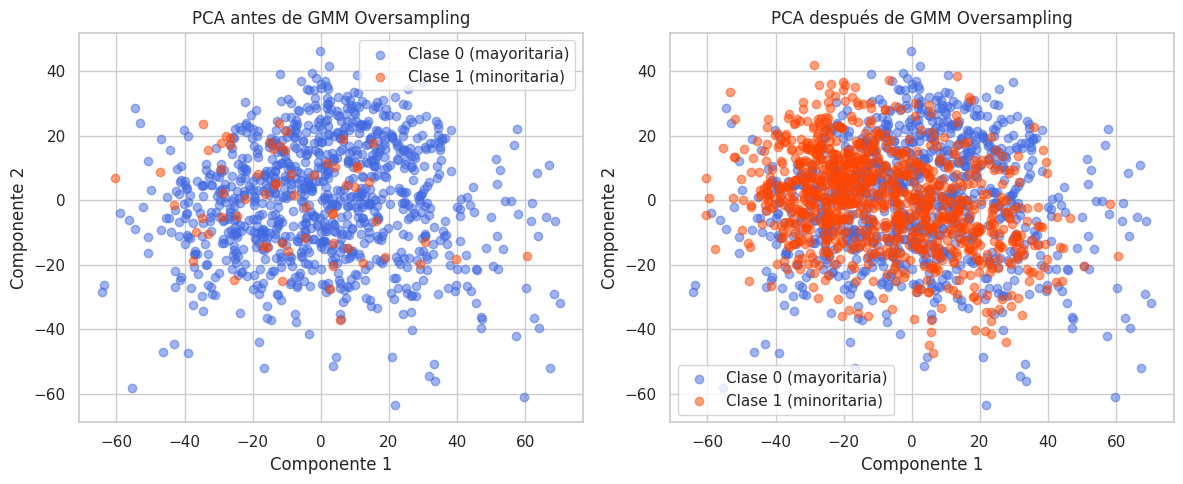

Varianza explicada antes de GMM: [0.35523541 0.20790034]
Varianza explicada después de GMM: [0.34665042 0.21177226]


In [ ]:
#@title PCA antes y después de GMM Oversampling

def pca_before_after_gmm(X, y, n_components_gmm=2, synth_multiplier=1.0, random_state=42):

    # ===========================
    # 1) PCA ANTES DEL GMM
    # ===========================
    pca_before = PCA(n_components=2)
    X_pca = pca_before.fit_transform(X)

    # ===========================
    # 2) Generar datos sintéticos con GMM
    # ===========================

    # Separar minoría y mayoría
    df = X.copy()
    df["Comp"] = y

    df_min = df[df["Comp"] == 1].reset_index(drop=True)
    df_maj = df[df["Comp"] == 0].reset_index(drop=True)

    # Número target de la minoría
    target_size = int(len(df_maj) * synth_multiplier)
    n_to_generate = max(target_size - len(df_min), 0)

    # Ajustar GMM
    gmm = GaussianMixture(
        n_components=n_components_gmm,
        covariance_type='full',
        random_state=random_state
    )
    gmm.fit(df_min.drop(columns=["Comp"]))

    print(f"Generando {n_to_generate} muestras sintéticas con GMM...")

    # Generar muestras
    if n_to_generate > 0:
        synthetic_features, _ = gmm.sample(n_to_generate)
        synthetic_min = pd.DataFrame(
            synthetic_features,
            columns=df_min.drop(columns=["Comp"]).columns
        )
        synthetic_min["Comp"] = 1
    else:
        synthetic_min = pd.DataFrame(columns=df.columns)

    # Dataset aumentado
    df_aug = pd.concat([df_maj, df_min, synthetic_min], ignore_index=True)
    X_res = df_aug.drop(columns=["Comp"])
    y_res = df_aug["Comp"]

    # ===========================
    # 3) PCA DESPUÉS DEL GMM
    # ===========================
    X_res_pca = pca_before.transform(X_res)

    # ===========================
    # 4) Visualización comparativa
    # ===========================

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Antes del GMM ---
    axs[0].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
                   c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
    axs[0].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
                   c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
    axs[0].set_title("PCA antes de GMM Oversampling")
    axs[0].set_xlabel("Componente 1")
    axs[0].set_ylabel("Componente 2")
    axs[0].legend()

    # --- Después del GMM ---
    axs[1].scatter(X_res_pca[y_res == 0, 0], X_res_pca[y_res == 0, 1],
                   c='royalblue', label='Clase 0 (mayoritaria)', alpha=0.5)
    axs[1].scatter(X_res_pca[y_res == 1, 0], X_res_pca[y_res == 1, 1],
                   c='orangered', label='Clase 1 (minoritaria)', alpha=0.5)
    axs[1].set_title("PCA después de GMM Oversampling")
    axs[1].set_xlabel("Componente 1")
    axs[1].set_ylabel("Componente 2")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # ===========================
    # 5) Varianza explicada
    # ===========================
    print("Varianza explicada antes de GMM:", pca_before.explained_variance_ratio_)
    print("Varianza explicada después de GMM:", pca_after.explained_variance_ratio_)

    return X_res, y_res

X_res, y_res = pca_before_after_gmm(X, y, n_components_gmm=2, synth_multiplier=1.0)

Clase minoritaria = 1.0 (62 muestras)
Clase mayoritaria = 0.0 (974 muestras)
Generando 912 muestras sintéticas con GMM...


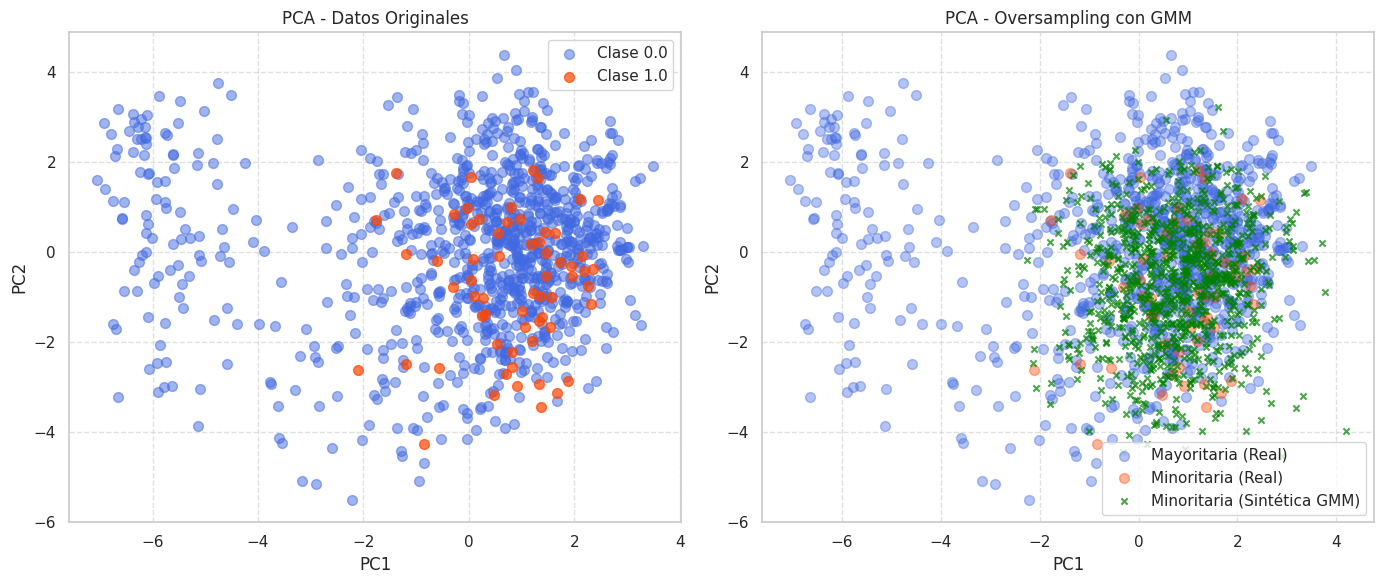

Varianza explicada por los 2 componentes PCA:
[0.12162579 0.06737667]


In [ ]:
#@title Visualizacion de GMM con PCA
def pca_gmm_visualization(
    X, y,
    n_components_gmm=3,
    balance_classes=True,
    random_state=42
):
    """
    Visualiza cómo cambia la distribución de datos al generar muestras sintéticas
    usando Gaussian Mixture Models (GMM).

    - Escala los datos.
    - Entrena un GMM solo con la clase minoritaria.
    - Genera suficientes datos sintéticos para balancear.
    - Proyecta todo con PCA.
    - Muestra gráficos comparativos.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from sklearn.mixture import GaussianMixture
    from sklearn.decomposition import PCA
    from collections import Counter
    import pandas as pd

    # =============================
    # 1. Identificar clases
    # =============================

    class_counts = Counter(y)
    minority_class = min(class_counts, key=class_counts.get)
    major_class = max(class_counts, key=class_counts.get)

    n_minority = class_counts[minority_class]
    n_major = class_counts[major_class]

    print(f"Clase minoritaria = {minority_class} ({n_minority} muestras)")
    print(f"Clase mayoritaria = {major_class} ({n_major} muestras)")

    # =============================
    # 2. Estandarizar datos
    # =============================

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Muestras minoritarias escaladas
    X_minority = X_scaled[y == minority_class]

    # =============================
    # 3. Ajustar GMM solo con la minoría
    # =============================

    if len(X_minority) < n_components_gmm:
        print("Advertencia: muy pocos datos para tantos componentes de GMM.")
        print(f"Reduciendo n_components_gmm a {len(X_minority)}.")
        n_components_gmm = len(X_minority)

    gmm = GaussianMixture(
        n_components=n_components_gmm,
        covariance_type="full",
        random_state=random_state
    )
    gmm.fit(X_minority)

    # =============================
    # 4. Cantidad a generar
    # =============================

    if balance_classes:
        n_to_generate = n_major - n_minority
        print(f"Generando {n_to_generate} muestras sintéticas con GMM...")
    else:
        n_to_generate = n_minority
        print(f"Generando {n_to_generate} muestras sintéticas (doblando minoría)...")

    # Evitar casos negativos
    n_to_generate = max(n_to_generate, 1)

    # =============================
    # 5. Generar sintéticos escalados
    # =============================

    X_syn_minority = gmm.sample(n_to_generate)[0]

    # =============================
    # 6. PCA de reales y sintéticos
    # =============================

    pca = PCA(n_components=2, random_state=42)
    pca.fit(X_scaled)

    X_pca_real = pca.transform(X_scaled)
    X_pca_syn = pca.transform(X_syn_minority)

    idx_major = (y == major_class)
    idx_minor = (y == minority_class)

    # =============================
    # 7. Gráficos
    # =============================

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # --- Antes ---
    axs[0].scatter(
        X_pca_real[idx_major, 0], X_pca_real[idx_major, 1],
        c="royalblue", alpha=0.5, label=f"Clase {major_class}", s=50
    )
    axs[0].scatter(
        X_pca_real[idx_minor, 0], X_pca_real[idx_minor, 1],
        c="orangered", alpha=0.7, label=f"Clase {minority_class}", s=50
    )
    axs[0].set_title("PCA - Datos Originales")
    axs[0].set_xlabel("PC1")
    axs[0].set_ylabel("PC2")
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # --- Después con Sintéticos ---
    axs[1].scatter(
        X_pca_real[idx_major, 0], X_pca_real[idx_major, 1],
        c="royalblue", alpha=0.4, label="Mayoritaria (Real)", s=50
    )
    axs[1].scatter(
        X_pca_real[idx_minor, 0], X_pca_real[idx_minor, 1],
        c="orangered", alpha=0.4, label="Minoritaria (Real)", s=50
    )
    axs[1].scatter(
        X_pca_syn[:, 0], X_pca_syn[:, 1],
        c="green", marker='x', alpha=0.7,
        label=f"Minoritaria (Sintética GMM)", s=20
    )
    axs[1].set_title("PCA - Oversampling con GMM")
    axs[1].set_xlabel("PC1")
    axs[1].set_ylabel("PC2")
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # =============================
    # 8. Info de varianza
    # =============================
    print("Varianza explicada por los 2 componentes PCA:")
    print(pca.explained_variance_ratio_)

    # =============================
    # 9. Devolver datos sintéticos (opcional)
    # =============================
    return X_syn_minority
X_syn = pca_gmm_visualization(X, y, n_components_gmm=3)

In [ ]:
#@title Aplicando solo GaussianMixture - Split 70-30
from sklearn.mixture import GaussianMixture

def gmm_oversampling_train_test(X, y, test_size=0.5, synth_multiplier=1.0, n_components=3, random_state=42):
    """
    Oversampling SOLO con Gaussian Mixture Models (GMM) aplicado al TRAIN (70-30).

    synth_multiplier:
        1.0  => igualar a la clase mayoritaria
        >1   => generar más que la clase mayoritaria

    n_components: número de mezclas gaussianas para modelar la distribución de la minoría.
    """

    # 1) División real estratificada 70-30
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )
    bool_cols = X_train.select_dtypes(include=["bool"]).columns
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols]  = X_test[bool_cols].astype(int)

    # 3) Separar clases en el TRAIN
    df_train = X_train.copy()
    df_train['Comp'] = y_train

    df_min = df_train[df_train['Comp'] == 1].reset_index(drop=True)
    df_maj = df_train[df_train['Comp'] == 0].reset_index(drop=True)

    # 4) Revisar tamaño de la minoría
    if len(df_min) < n_components:
        print(f"La minoría tiene menos observaciones que los n_components = {n_components}.")
        print("No se aplica GMM. Se devuelve TRAIN original.")
        return X_train, X_test, y_train, y_test

    # 5) Ajustar un GMM a la minoría (solo X)
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=random_state
    )
    gmm.fit(df_min.drop(columns=['Comp']))

    # 6) Cantidad de sintéticos necesarios
    target_size = int(len(df_maj) * synth_multiplier)
    n_to_generate = max(target_size - len(df_min), 0)

    print(f"Generando {n_to_generate} registros sintéticos con GMM...")

    # 7) Generar sintéticos si toca
    if n_to_generate > 0:
        synthetic_features, _ = gmm.sample(n_to_generate)
        synthetic_min = pd.DataFrame(
            synthetic_features,
            columns=df_min.drop(columns=['Comp']).columns
        )
        synthetic_min['Comp'] = 1
    else:
        synthetic_min = pd.DataFrame(columns=df_train.columns)

    # 8) Concatenar mayoría + minoría + sintéticos
    df_aug = pd.concat([df_maj, df_min, synthetic_min], ignore_index=True)
    df_aug = df_aug.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # 9) Separar X_train e y_train finales
    X_train_balanced = df_aug.drop(columns=['Comp'])
    y_train_balanced = df_aug['Comp']

    return X_train_balanced, X_test, y_train_balanced, y_test

In [ ]:
X_train1, X_test1, y_train1, y_test1 = gmm_oversampling_train_test(XX, yy)

Generando 456 registros sintéticos con GMM...


In [ ]:
X_train1.head(50)

,tipodepaciente,edad,sexo,IPA,Consumo alcohol,Peso,Talla,IMC,FC,PAS,Comorbilidad rxcv,Diabetes,EPOC,Fibrilación atrial,Demencia (Dxco Médico),Enfermedad arterial periférica,Hipertensión arterial,fevi,IECAs/ARAII,BB,creatinina,potasio,BUN,NYHA_1.0,NYHA_2.0,NYHA_3.0,NYHA_4.0,AHA_1.0,AHA_2.0,AHA_3.0,AHA_4.0,estadocivil_0.0,estadocivil_1.0,estadocivil_2.0,arearesidencia_0.0,arearesidencia_1.0,regimensalud_0.0,regimensalud_1.0,educacion_0.0,educacion_1.0,educacion_2.0,educacion_3.0,educacion_4.0
0,1.000000,55.000000,1.000000,0.000000,0.000000,60.200000,1.640000,22.382510,68.000000,88.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,1.000000,0.860000,4.150000,16.110000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,0.999623,66.754028,0.174412,0.000272,-0.001020,62.875271,1.641197,23.440933,44.459741,107.656033,-0.127013,0.366172,-0.435651,-0.760860,-0.000806,0.512425,0.201934,16.198466,0.403687,0.304375,1.535748,4.313794,48.537636,0.000821,0.553753,-0.433505,0.881172,-0.000869,-0.326960,1.325306,-0.001866,0.312971,0.689146,-0.001839,0.391280,0.606430,1.122041,-0.121510,0.594281,0.404486,0.001566,-0.000066,-0.000555
2,1.000000,56.000000,1.000000,0.000000,0.000000,56.300000,1.600000,21.992188,71.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.000000,1.000000,1.000000,1.220000,5.000000,27.020000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
3,1.000000,86.000000,1.000000,0.000000,0.000000,75.100000,1.750000,24.522449,88.000000,94.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,1.000000,1.000000,1.630000,4.130000,48.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
4,1.000000,62.000000,0.000000,0.000000,0.000000,67.000000,1.660000,24.300000,58.000000,88.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,49.000000,1.000000,1.000000,1.890000,4.490000,21.800000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
5,1.000000,38.000000,1.000000,0.000000,0.000000,69.000000,1.830000,20.603780,69.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,1.090000,4.250000,14.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
6,1.000000,50.000000,0.000000,0.000000,0.000000,58.000000,1.550000,24.141519,69.000000,142.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,63.000000,0.000000,0.000000,1.100000,4.440000,14.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
7,1.000000,63.000000,1.000000,0.000000,0.000000,66.000000,1.620000,25.148605,40.000000,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.000000,1.000000,1.210000,3.600000,24.300000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
8,1.000000,71.000000,1.000000,0.000000,0.000000,68.000000,1.670000,24.382373,61.000000,90.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,31.000000,1.000000,1.000000,1.070000,4.200000,17.300000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.0

In [ ]:
df_resultados = run_all_models(X_train, y_train, X_test, y_test)

# **PRUEBA: media antes o despues**

In [ ]:
#@title Media antes del split
df_mean = chagas.copy()

y = df_mean['Complicaciones cardiovasculares']
X = df_mean.drop(columns=['Complicaciones cardiovasculares'])

mean = X.mean(numeric_only=True)
X_mean = X.fillna(mean)

X_train, X_test, y_train, y_test = train_test_split(
    X_mean, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
df_resultados = run_all_models(X_train, y_train, X_test, y_test)


=== Entrenamiento sin sampling ===
Tamaño X_train: (725, 77), X_test: (311, 77)
Tamaño y_train: (725,), y_test: (311,)

Distribución de clases en y_train:
Complicaciones cardiovasculares
0.0    682
1.0     43
Name: count, dtype: int64

Distribución de clases en y_test:
Complicaciones cardiovasculares
0.0    292
1.0     19
Name: count, dtype: int64

=== Resultados del Test (70-30) ===
   Fold          Model  Accuracy  Precision    Recall  F1-Score  Specificity  \
2     1  Random Forest  0.900322   0.227273  0.263158  0.243902     0.941781   
3     1  Decision Tree  0.598071   0.085938  0.578947  0.149660     0.599315   
0     1            KNN  0.919614   0.125000  0.052632  0.074074     0.976027   
4     1   Bagging (DT)  0.852090   0.034483  0.052632  0.041667     0.904110   
1     1      SVM (RBF)  0.938907   0.000000  0.000000  0.000000     1.000000   
5     1  AdaBoost (DT)  0.938907   0.000000  0.000000  0.000000     1.000000   
6     1        XGBoost  0.938907   0.000000  0.00000

In [ ]:
#@title Media despues del split
df = chagas.copy()

y = df['Complicaciones cardiovasculares']
X = df.drop(columns=['Complicaciones cardiovasculares'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

train_means = X_train.mean()
X_train = X_train.fillna(train_means)
X_test = X_test.fillna(train_means)

df_resultados = run_all_models(X_train, y_train, X_test, y_test)


=== Entrenamiento sin sampling ===
Tamaño X_train: (725, 77), X_test: (311, 77)
Tamaño y_train: (725,), y_test: (311,)

Distribución de clases en y_train:
Complicaciones cardiovasculares
0.0    682
1.0     43
Name: count, dtype: int64

Distribución de clases en y_test:
Complicaciones cardiovasculares
0.0    292
1.0     19
Name: count, dtype: int64

=== Resultados del Test (70-30) ===
   Fold          Model  Accuracy  Precision    Recall  F1-Score  Specificity  \
2     1  Random Forest  0.903537   0.238095  0.263158  0.250000     0.945205   
3     1  Decision Tree  0.598071   0.085938  0.578947  0.149660     0.599315   
0     1            KNN  0.919614   0.125000  0.052632  0.074074     0.976027   
4     1   Bagging (DT)  0.852090   0.034483  0.052632  0.041667     0.904110   
1     1      SVM (RBF)  0.938907   0.000000  0.000000  0.000000     1.000000   
5     1  AdaBoost (DT)  0.938907   0.000000  0.000000  0.000000     1.000000   
6     1        XGBoost  0.938907   0.000000  0.00000

# **Fuzzy C-Means**

In [ ]:
pip install scikit-fuzzy -q

In [ ]:
df_full = chagas.dropna(axis=1)
X = df_full.drop(columns=['Complicaciones cardiovasculares'])
y = df_full['Complicaciones cardiovasculares']
#df_full.info()

In [ ]:
from sklearn.preprocessing import StandardScaler
import skfuzzy as fuzz

# Convertir bool → float (skfuzzy trabaja con floats)
X = X.copy()
bool_cols = X.select_dtypes('bool').columns
X[bool_cols] = X[bool_cols].astype(float)

# Estandarizar todas las variables (muy importante para clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# skfuzzy espera forma (features, samples)
X_fcm = X_scaled.T
print(X_fcm.shape)  # (n_features, n_samples)

(43, 1036)


In [ ]:
n_clusters = 2   # puedes probar 2, 3, 4...
m = 2.0          # grado de difusidad típico

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fcm,
    c=n_clusters,
    m=m,
    error=1e-5,
    maxiter=1000,
    init=None
)

print("Centroides (en espacio estandarizado):")
print(cntr)
print("FPC (Fuzzy Partition Coefficient):", fpc)

# u tiene forma (n_clusters, n_samples)
u = u.T  # ahora (n_samples, n_clusters)

Centroides (en espacio estandarizado):
[[ 9.36648801e-07  7.78030845e-07  1.65834079e-07 -4.11322823e-08
  -4.31335969e-07 -4.01774130e-07  3.30270943e-08 -4.77512703e-07
   1.04329084e-07 -2.18003715e-07  2.76299179e-07  1.77133125e-07
   2.25168778e-07  3.20346191e-07 -8.43919250e-09  1.13540361e-07
   4.20021686e-07 -8.92150127e-07  8.71750127e-07  9.72042600e-07
   1.59971085e-07 -7.19815518e-08  5.10830552e-07 -1.09926949e-06
   1.92429462e-07  6.19082952e-07  1.89978293e-07 -9.28219451e-07
  -3.54217788e-07  8.65698206e-07  4.19651680e-08  5.23301458e-07
  -5.21035584e-07 -2.85412396e-09  5.26379555e-07 -5.26379555e-07
   2.35323826e-07 -2.35323826e-07 -2.51003133e-07  3.84171045e-07
  -1.66081726e-07 -1.22983031e-07  1.13938989e-08]
 [-9.36650063e-07 -7.78031478e-07 -1.65834241e-07  4.11322237e-08
   4.31336356e-07  4.01774193e-07 -3.30272838e-08  4.77512897e-07
  -1.04329132e-07  2.18003827e-07 -2.76299497e-07 -1.77133372e-07
  -2.25169027e-07 -3.20346544e-07  8.43913256e-09 -1

In [ ]:
y_array = y.values.astype(float)

risk_by_cluster = []
for j in range(n_clusters):
    # promedio ponderado del outcome usando las pertenencias como pesos
    avg_risk = np.average(y_array, weights=u[:, j])
    risk_by_cluster.append(avg_risk)
    print(f"Cluster {j} – promedio ponderado de Complicaciones:", avg_risk)

high_risk_idx = int(np.argmax(risk_by_cluster))
print("Cluster de mayor riesgo:", high_risk_idx)

# Score continuo de severidad = pertenencia al cluster de alto riesgo
severity_score = u[:, high_risk_idx]

df_full = df_full.copy()
df_full['severity_score'] = severity_score

Cluster 0 – promedio ponderado de Complicaciones: 0.0598455646625339
Cluster 1 – promedio ponderado de Complicaciones: 0.0598455550285853
Cluster de mayor riesgo: 0


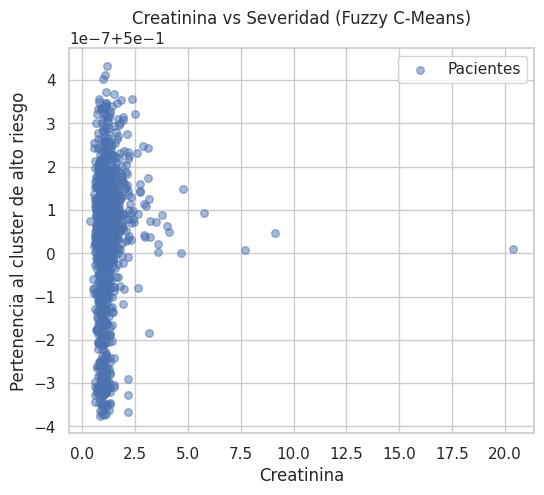

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df_full['creatinina'], df_full['severity_score'],
            alpha=0.5, s=30, label='Pacientes')
plt.xlabel('Creatinina')
plt.ylabel('Pertenencia al cluster de alto riesgo')
plt.title('Creatinina vs Severidad (Fuzzy C-Means)')
plt.grid(True)
plt.legend()
plt.show()

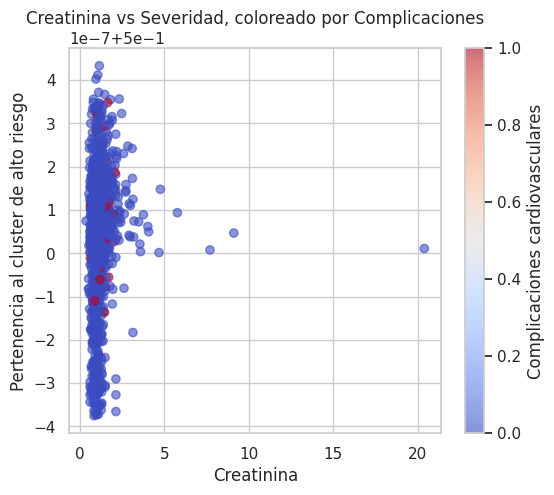

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_full['creatinina'],
            df_full['severity_score'],
            c=df_full['Complicaciones cardiovasculares'],
            cmap='coolwarm', alpha=0.6)
plt.xlabel('Creatinina')
plt.ylabel('Pertenencia al cluster de alto riesgo')
plt.title('Creatinina vs Severidad, coloreado por Complicaciones')
plt.colorbar(label='Complicaciones cardiovasculares')
plt.grid(True)
plt.show()

In [ ]:
tmp = df_full[['creatinina', 'severity_score']].copy()
tmp = tmp.sort_values('creatinina')

# Índice donde la severidad está más cerca de 0.5
idx_boundary = np.argmin(np.abs(tmp['severity_score'] - 0.5))
boundary_creat = tmp['creatinina'].iloc[idx_boundary]
boundary_score = tmp['severity_score'].iloc[idx_boundary]

print("Boundary aproximado en creatinina:")
print("  creatinina ≈", boundary_creat)
print("  severity_score ≈", boundary_score)

Boundary aproximado en creatinina:
  creatinina ≈ 1.19
  severity_score ≈ 0.5000000001199875
